# Gemini Logical Dialect Demo

In this notebook, we go over the dialect used to program on the Gemini-QEC neutral atom quantum computer, as well as details about our compiler infrastructure.

## Installation

To get started, you can create a virtual environment and run `pip install bloqade-lanes[sim, visualization]`.

## Example Single Qubit Kernel

We first define a simple circuit consisting of one logical qubit encoded in the [[7, 1, 3]] Steane code.

<img src="./star_demo_imgs/steane_qubit_diagram.png" width="400">

In [ ]:
# Language used to program circuits
from bloqade.gemini import logical
from bloqade import squin
# Used to compile our circuit to physical qubits and operations
from bloqade.gemini import GeminiLogicalSimulator

# For defining math.pi constants
import math
# For defining lists of gates in broadcast statements
from kirin.dialects import ilist
# For plotting and analysis
import matplotlib.pyplot as plt
import numpy as np
import io
from IPython.display import Image, display
from collections import Counter
# For decoding
from bloqade.decoders import BpLsdDecoder

In [ ]:
# We define our kernel with one logical qubit.
@logical.kernel(aggressive_unroll=True, verify=True)
def simple_state_prep_singleq():
    reg = squin.qalloc(1)
    squin.u3(0.1,0.2,0.3,reg[0])
    return logical.terminal_measure(reg)
# We then run our logical compiler on our kernel to compile the logical circuit to physical gates on atoms.
task_state_prep = GeminiLogicalSimulator().task(simple_state_prep_singleq)

In [ ]:
# We visualize the circuit. Note that we are preparing a qubit in the [[7, 1, 3]] Steane code.
task_state_prep.noiseless_tsim_circuit.diagram(width=500)

In [ ]:
# Allows us to visualize the atom program as a popup in the notebook
%matplotlib qt

In [ ]:
# We visualize the atom move program on physical qubits.
task_state_prep.visualize()

## Single-Qubit Kernel with Transversal Gate

We now add a single-qubit transversal Hadamard gate and see how it is decomposed into native gates.

In [ ]:
@logical.kernel(aggressive_unroll=True, verify=True)
def simple_transversal_hadamard():
    reg = squin.qalloc(1)
    squin.u3(0.1,0.2,0.3,reg[0])
    squin.h(reg[0])
    return logical.terminal_measure(reg)
task_hadamard = GeminiLogicalSimulator().task(simple_transversal_hadamard)

In [ ]:
task_hadamard.noiseless_tsim_circuit.diagram(width=500)

In [ ]:
task_hadamard.visualize()

## Native Gate Set on Gemini
- Global/Local R(φ, θ) where φ is the axis in the X-Y plane to rotate around, and θ is the magnitude of the rotation
    - Specifically, SX/SX^dag, SY/SY^dag, X, and Y are currently the set of native single-qubit gates.
- Global Rz(θ)
- Global CZ
- Global Measurement

Writing in this native gate set will yield better performance as it would require less physical operations on the machine.

## Two-Logical Qubit Bell-State Preparation

We now define a kernel that prepares a two-qubit Bell state.

In [ ]:
@logical.kernel(aggressive_unroll=True, verify=True)
def simple_bell_state_prep_nonnative():
    reg = squin.qalloc(2)
    squin.h(reg[0])
    squin.cx(reg[0], reg[1])
    return logical.terminal_measure(reg)
task_bell_nonnative = GeminiLogicalSimulator().task(simple_bell_state_prep_nonnative)

In [ ]:
task_bell_nonnative.noiseless_tsim_circuit.diagram(width=500)

If we program the circuit with the native gate set in mind, we can obtain a circuit with less layers.

In [ ]:
@logical.kernel(aggressive_unroll=True, verify=True)
def simple_bell_state_prep():
    reg = squin.qalloc(2)
    # For the GHZ state we just need q0 to be in |+>, so applying sqrt(Y) suffices
    squin.u3(math.pi/2, 0.0, 0.0, reg[0])
    # We use the decomposition of CX_{c, t} = sqrt(Y)_t CZ_{c, t} sqrt(Y)^dag_t
    # We apply sqrt(Y)^dag on q1 before injection
    squin.u3(-math.pi/2, 0.0, 0.0, reg[1])
    # And then apply CZ followed by sqrt(y)
    squin.cz(reg[0], reg[1])
    squin.sqrt_y(reg[1])
    return logical.terminal_measure(reg)
task_bell = GeminiLogicalSimulator().task(simple_bell_state_prep)

In [ ]:
task_bell.noiseless_tsim_circuit.diagram(width=500)

In [ ]:
task_bell.visualize()

## Multiple CZ Gates, Use-Case: 4-Qubit GHZ State

We now explore a kernel with multiple CZ gates where we define a 4 qubit GHZ state.

<img src="./star_demo_imgs/4q_ghz_state.png" width="400">

In [ ]:
@logical.kernel(aggressive_unroll=True, verify=True)
def four_qubit_bell_state():
    reg = squin.qalloc(4)
    # We apply sqrt_y on Q0, and sqrt_y^dag on the remaining qubits (absorbing the gate from CX)
    squin.u3(math.pi/2, 0.0, 0.0, reg[0])
    squin.u3(-math.pi/2, 0.0, 0.0, reg[1])
    squin.u3(-math.pi/2, 0.0, 0.0, reg[2])
    squin.u3(-math.pi/2, 0.0, 0.0, reg[3])

    # We then apply the CZ's followed by sqrt_y on the target qubits
    squin.cz(reg[0], reg[1])
    squin.sqrt_y(reg[1])
    squin.cz(reg[0], reg[2])
    squin.sqrt_y(reg[2])
    squin.cz(reg[1], reg[3])
    squin.sqrt_y(reg[3])
    return logical.terminal_measure(reg)
task_bell_4q = GeminiLogicalSimulator().task(four_qubit_bell_state)

In [ ]:
task_bell_4q.noiseless_tsim_circuit.diagram(width=700)

In [ ]:
task_bell_4q.visualize()

You might wonder why there appear to be intermediate, potentially "unnecessary" atom movements. That is because, for the Gemini-QEC machine, our machine has a small calibrated move-set, defined below.

<img src="./star_demo_imgs/gemini_logical_buses.png" width="700">

> Note: we have to do left and right "column" moves separately

And regarding the layout of our atoms on the physical architecture, we "interleave" our logical qubits to reduce the distance that our atoms have to move across the "gap" on the physical-level.

<img src="./star_demo_imgs/gemini_interleaved_layout.png" width="700">

In [ ]:
# Lower and upper bound of fidelity are on branching on control flow logic.
# This is the probability of having no errors.
lower_fid, upper_fid = task_bell_4q.fidelity_bounds()
print(upper_fid)

0.35312675552631917


## Revisiting 4-Qubit GHZ State: Adding Explicit Parallelism

You might have noticed in the above circuit that the CZ layers were serialized, but the CZ gates from qubits (0, 2) and (1, 3) could be done in parallel. We can explicitly tell the compiler to do these gates in parallel by using the "broadcast" statement.

In [ ]:
@logical.kernel(aggressive_unroll=True, verify=True)
def four_qubit_bell_state_parallel():
    reg = squin.qalloc(4)
    # We apply sqrt_y to q0
    squin.u3(math.pi/2, 0.0, 0.0, reg[0])
    # We broadcast sqrt_y^dag to the remaining qubits
    squin.broadcast.u3(-math.pi/2, 0.0, 0.0, ilist.IList([reg[1], reg[2], reg[3]]))

    # We apply the first CZ layer
    squin.cz(reg[0], reg[1])
    squin.sqrt_y(reg[1])
    # We apply the second CZ layer, broadcasted across the qubits
    squin.broadcast.cz(ilist.IList([reg[0], reg[1]]), ilist.IList([reg[2], reg[3]]))
    squin.broadcast.sqrt_y(ilist.IList([reg[2], reg[3]]))
    return logical.terminal_measure(reg)
task_bell_4q_parallel = GeminiLogicalSimulator().task(four_qubit_bell_state_parallel)

In [ ]:
task_bell_4q_parallel.noiseless_tsim_circuit.diagram(width=700)

In [ ]:
task_bell_4q_parallel.visualize()

In [ ]:
# We again print the probability of no errors in the circuit and observe that it is higher
# due to the parallelization of the last CZ layer.
lower_fid, upper_fid = task_bell_4q_parallel.fidelity_bounds()
print(upper_fid)

0.38644380901678116


## Example Analysis

We now go through a workflow of how you might simulate and analyze the results of your circuit.

### Some prototype stdutils functions: detectors and observables
We break abstraction a bit between physical and logical qubits. Each logical measurement is a batch of 7 physical measurements as indexed by the following diagram.

In order to correct the errors from a Steane code, we need to inform the decoder and detector error model of the decoding steps. This can be done by defining the **detectors** and the **observables**.

For the Steane code, the detectors are four-qubit parity patches corresponding to the three plaquettes of the code; in the following render the default detectors are red/green/purple patches.

For the Steane code, the obsevables are three-qubit parity lines corresponding to edges of the code; in the following render is default observable are the black line.

In [ ]:
def render_steane_code_qubit(ax:plt.Axes | None = None,center:tuple[float,float]=(0,0), figsize=(5,5))->plt.Axes:
    if ax is None:
        fig,ax = plt.subplots(figsize=figsize)
        ax.set_aspect("equal")
        ax.set_xlim([-2+center[0],2+center[0]])
        ax.set_ylim([-2+center[1],2+center[1]])
        ax.axis("off")
    RED = "#EF2F55"
    PURPLE = "#670EFF"
    GREEN = "#57BC13"

    pos_center = np.zeros([2,7])
    pos_center[:,1::] = np.array([np.cos(np.linspace(0,2*np.pi,7)[0:6])*1.5,1.5*np.sin(np.linspace(0,2*np.pi,7)[0:6])])
    pos_center += np.array(center).reshape(2,1)

    ax.scatter(pos_center[0],pos_center[1],color="w",s=800,zorder=100,edgecolors="k")
    indexing = [2,0,3,6,4,5,1]
    for xi, yi, label in zip(pos_center[0],pos_center[1],indexing):
        ax.text(xi,yi,str(label),ha="center",va="center",zorder=200)

    ax.fill([pos_center[0,x] for x in [0,2,3,4]],[pos_center[1,x] for x in [0,2,3,4]],color=RED)
    ax.fill([pos_center[0,x] for x in [0,4,5,6]],[pos_center[1,x] for x in [0,4,5,6]],color=GREEN)
    ax.fill([pos_center[0,x] for x in [0,6,1,2]],[pos_center[1,x] for x in [0,6,1,2]],color=PURPLE)
    logical_label = [indexing.index(5), indexing.index(1), indexing.index(0)]
    ax.plot(pos_center[0,logical_label],pos_center[1,logical_label],color="k",ls="-",linewidth=5,zorder=50)
    
    return ax

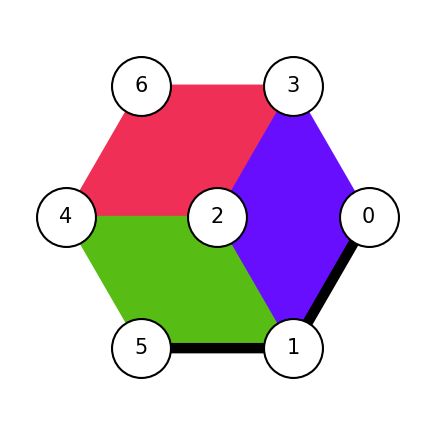

In [ ]:
def show_inline(ax, dpi=150):
    buf = io.BytesIO()
    ax.figure.savefig(buf, format="png", bbox_inches="tight", dpi=dpi)
    plt.close(ax.figure)
    display(Image(data=buf.getvalue()), width=200)

show_inline(render_steane_code_qubit(figsize=(3.5, 3.5)))

Let's define some default functions which use the `squin.set_detector` and `squin.set_observable` functions, which annotate the program for later analysis to generate the detector error model.

For the purposes of our demonstration, let's use the two-qubit GHZ state.

Note that we have attempted to optimize our kernel for the hardware implementation.

In [ ]:
@logical.kernel(aggressive_unroll=True, verify=True)
def main():
    reg = squin.qalloc(3)
    # We apply the same gate sequence used to prepare a two-qubit GHZ state
    squin.u3(math.pi/2, 0.0, 0.0, reg[0])
    squin.u3(-math.pi/2, 0.0, 0.0, reg[1])
    squin.cz(reg[0], reg[1])
    squin.sqrt_y(reg[1])

    return logical.default_post_processing(reg) # Return the physical measurements

task = GeminiLogicalSimulator().task(main)

The `task` has several attributes. The key attributes are:
| Attribute         | Description                          |
|-------------------|--------------------------------------|
| `task.run`        | Run the task, sampling bitstrings from the noisy distribution |
| `task.noiseless_tsim_circuit`             | The underlying physical circuit without noise        |
| `task.tsim_circuit`             | The underlying physical circuit including noise             |
| `task.detector_error_model`           | The DEM associated with the noisy circuit       |
| `task.visualize`     | Render an interactive atom move.   |

## Rendering of the noiseless circuit:

In [ ]:
task.noiseless_tsim_circuit.diagram(height=task.noiseless_tsim_circuit.num_qubits*25)

## Rendering of the noisy circuit:
Includes 1 and 2 qubit gate error, spectator errors, and move errors.

Note: compiler currently does not yet account for the fact that the angle injection gate can be merged in with the first layer of the state prep kernel. But when programming on the hardware, these are the kinds of games you can play to minimize the layers required.

In [ ]:
task.tsim_circuit.diagram(height=task.tsim_circuit.num_qubits*25)

## Running the task
The `task.run` attribute compiles the task to tsim and then samples from it. Note that the majority of the time is spent compiling the task; the sampler is very fast.

In [ ]:
result = task.run(1, with_noise=True)
result_wo_noise = task.run(1, with_noise=False)

In [ ]:
# After recompilation, the task runs very quickly.
result = task.run(10000, with_noise=True)
result_wo_noise = task.run(10000, with_noise=False)

The `result` object has several meaningful attributes that are useful for analysis:
| Attribute         | Description                          |
|-------------------|--------------------------------------|
| `result.return_values`        | The values returned from the kernel |
| `result.detectors` | The parity values of the annotated detectors |
| `result.observables` | The parity values of the annotated observables |
| `result.physical` | The physical qubit measurements |

For each value, the zeroth dimension is the shot index.
- `detectors` are a flattened list of `[ [detectors of qubit 0 ], [detectors of qubit 1] [ ... ] ]`
- `observables` are a list of `[ obsevable of qubit 0, observable of qubit 1, ... ]`
- `physical` is a nested list of `[[7 physical measurements of qubit 0], [7 physical measurements of qubit 1], ...]`

Indexing is in the same ordering of however the qubits were measured in the `logical.terminal_measure` statement.

In [ ]:
return_values = result.return_values
detectors = np.asarray(result.detectors)
observables = np.asarray(result.observables)
physical = np.asarray(result.measurements)
observables_without_noise = np.asarray(result_wo_noise.observables)

print(detectors.shape)
print(observables.shape)
print(physical.shape)

(10000, 9)
(10000, 3)
(10000, 21)


## Decoding and post-selection
Decoders can be inherited from elsewhere but follow a common pattern. Given the detector error model, flips to the logical qubits can be decoded based on the detector triggers. Because the code is linear, the corrected code is simply the XOR of the flips and the observables.

Alternatively, one may postselect on having no errors, or all detectors being zero.

In [ ]:
# Correct
flips = BpLsdDecoder(task.detector_error_model).decode(detectors)
observables_corrected = observables ^ flips
print("Average bits flipped:", np.average(flips))

# Postselect
post_selection = np.all(detectors == 0, axis=1)
observables_postselected = observables[post_selection, :]
print("Postselection rate:  ", len(observables_postselected) / len(observables))

Average bits flipped: 0.07076666666666667
Postselection rate:   0.7538


## Analysis 1: parity
For the GHZ state, we have the convenience of the final state being uniformly sampled from 00 or 11, with 01 or 10 indicating an error outside of the distribution. Thus, computing the parity of the observables can serve as a proxy of the fidelity of the distribution: parity 0 means no error, parity 1 means error, and the average parity is the error rate. Postselection and correction decreases the parity, meaning the final error is better!

In [ ]:
print("Average parity (before correction):", np.average(observables[:,0] ^ observables[:,1]))
print("Average parity (after correction):", np.average(observables_corrected[:,0] ^ observables_corrected[:,1]))
print("Average parity (after postselection):", np.average(observables_postselected[:,0] ^ observables_postselected[:,1]))

Average parity (before correction): 0.0787
Average parity (after correction): 0.0418
Average parity (after postselection): 0.0070310427169010346


### Some helper functions and standard utilities to analyze statistical divergence

In [ ]:
# helper functions to analyze statistical distribution of logical measurements
def get_hist(obs_array: np.ndarray):
    return Counter(map(lambda x: tuple(map(int, x)), obs_array[:]))

def kl_divergence(p_hist: Counter, q_hist: Counter) -> float:
    """Compute the KL divergence D_KL(P || Q) between two histograms."""
    total_p = sum(p_hist.values())
    total_q = sum(q_hist.values())
    if total_p == 0 or total_q == 0:
        return float("inf")  # Infinite divergence if one distribution is empty
    divergence = 0.0
    for key in p_hist:
        p_prob = p_hist[key] / total_p
        q_prob = q_hist.get(key, 0) / total_q
        if q_prob > 0:
            divergence += p_prob * math.log(p_prob / q_prob)
        else:
            divergence += p_prob * math.log(p_prob / (1e-10))  # Avoid log(0)
    return divergence



The Kullback-Leibler divergence $D_{KL}(P||Q)$ measures the dissimilarity between two probability distributions. When the KL divergence is zero, there is no loss when the noisy distribution (Q) is used to represent the perfect distribution (P). Similar to the parity measurement above, we find that the divergence is lower for corrected and postselected distributions. Note that the distribution is approximated from finite sampling (a simple frequentist bootstrap), so the KL divergence is an upper bound on the true distribution.

In [ ]:
observables_hist = get_hist(observables)
observables_decoded_hist = get_hist(observables_corrected)
observables_postselected_hist = get_hist(observables_postselected)
observables_wo_noise_hist = get_hist(observables_without_noise)

# compute and print the KL divergence between the histograms
print("KL divergence between noiseless and raw observables:",kl_divergence(observables_wo_noise_hist, observables_hist))
print("KL divergence between noiseless and decoded observables:",kl_divergence(observables_wo_noise_hist, observables_decoded_hist))
print("KL divergence between noiseless and post-selected observables:",kl_divergence(observables_wo_noise_hist, observables_postselected_hist))

KL divergence between noiseless and raw observables: 0.10925705274439955
KL divergence between noiseless and decoded observables: 0.06530556353272261
KL divergence between noiseless and post-selected observables: 0.007726853476873298


### Dos and do nots for kernels
A valid kernel for Gemini must:
1. Have less than or equal to 10 qubits
2. Only have a single non-Clifford gate per qubit, acting as a single-qubit gate as the first gate on each qubit
3. Measurement is in Z basis only.

<img src="./star_demo_imgs/gemini_mvp_capabilities.png" width="700">

Too many qubits

In [ ]:
try:
    @logical.kernel(aggressive_unroll=True, verify=True)
    def main():
        reg = squin.qalloc(12)
        squin.h(reg[0])
        squin.cx(reg[0], reg[1])

        return logical.default_post_processing(reg)

    task = GeminiLogicalSimulator().task(main)
except BaseException as e:
    print("Error during kernel definition or task creation:", e)

Error during kernel definition or task creation: 
Validation failed with 2 violation(s):

Gemini Logical Validation:
  - Qubit allocations exceeded 10.
      File 
"/Users/jasonhan/Desktop/qmain/personal-workspace/bloqade-lanes/.venv/lib/python3.12/site-packages/bloqade/qubit/st
dlib/_new.py", line 14, col 15

  - Qubit allocations exceeded 10.
      File 
"/Users/jasonhan/Desktop/qmain/personal-workspace/bloqade-lanes/.venv/lib/python3.12/site-packages/bloqade/qubit/st
dlib/_new.py", line 14, col 15



Repeated non-Clifford rotations

In [ ]:
try:
    @logical.kernel(aggressive_unroll=True, verify=True)
    def main():
        reg = squin.qalloc(12)
        squin.t(reg[0])
        squin.t(reg[0])
        squin.cx(reg[0], reg[1])

        return logical.default_post_processing(reg)

    task = GeminiLogicalSimulator().task(main)
except BaseException as e:
    print("Error during kernel definition or task creation:", e)

Error during kernel definition or task creation: 
Validation failed with 3 violation(s):

Gemini Logical Validation:
  - Qubit allocations exceeded 10.
      File 
"/Users/jasonhan/Desktop/qmain/personal-workspace/bloqade-lanes/.venv/lib/python3.12/site-packages/bloqade/qubit/st
dlib/_new.py", line 14, col 15

  - Qubit allocations exceeded 10.
      File 
"/Users/jasonhan/Desktop/qmain/personal-workspace/bloqade-lanes/.venv/lib/python3.12/site-packages/bloqade/qubit/st
dlib/_new.py", line 14, col 15

  - Non-clifford gate t can only be used for initial state preparation, i.e. as the first gate!
      File 
"/Users/jasonhan/Desktop/qmain/personal-workspace/bloqade-lanes/.venv/lib/python3.12/site-packages/bloqade/squin/st
dlib/broadcast/gate.py", line 9, col 11
   │  squin.cx(reg[0], reg[1])
   │  
  9│  return logical.default_post_processing(reg)
   │         ^^^^^^



Non-Clifford rotation not as the first gate (This is the same validation error)

In [ ]:
try:
    @logical.kernel(aggressive_unroll=True, verify=True)
    def main():
        reg = squin.qalloc(12)
        squin.h(reg[0])
        squin.cx(reg[0], reg[1])
        squin.t(reg[0])

        return logical.default_post_processing(reg)

    task = GeminiLogicalSimulator().task(main)
except BaseException as e:
    print("Error during kernel definition or task creation:", e)

Error during kernel definition or task creation: 
Validation failed with 3 violation(s):

Gemini Logical Validation:
  - Qubit allocations exceeded 10.
      File 
"/Users/jasonhan/Desktop/qmain/personal-workspace/bloqade-lanes/.venv/lib/python3.12/site-packages/bloqade/qubit/st
dlib/_new.py", line 14, col 15

  - Qubit allocations exceeded 10.
      File 
"/Users/jasonhan/Desktop/qmain/personal-workspace/bloqade-lanes/.venv/lib/python3.12/site-packages/bloqade/qubit/st
dlib/_new.py", line 14, col 15

  - Non-clifford gate t can only be used for initial state preparation, i.e. as the first gate!
      File 
"/Users/jasonhan/Desktop/qmain/personal-workspace/bloqade-lanes/.venv/lib/python3.12/site-packages/bloqade/squin/st
dlib/broadcast/gate.py", line 9, col 11
   │  squin.t(reg[0])
   │  
  9│  return logical.default_post_processing(reg)
   │         ^^^^^^



## Supplementary: 5-to-1 MSD Circuit

We additionally provide a kernel that is the same as the circuit used in the 5-to-1 logical magic state distillation experiment (https://www.nature.com/articles/s41586-025-09367-3) for visualizing atom moves.

<img src="./star_demo_imgs/msd_logical_circuit.png" width="700">

In [ ]:
theta_val = math.acos(1/math.sqrt(3))

@logical.kernel(aggressive_unroll=True, verify=True)
def msd_logical_parallel_kernel():
    reg = squin.qalloc(5)
    
    squin.broadcast.u3(theta_val, math.pi/4, 0.0, reg)

    squin.broadcast.sqrt_x(ilist.IList([reg[0], reg[1], reg[4]]))

    squin.broadcast.cz(ilist.IList([reg[0], reg[2]]), ilist.IList([reg[1], reg[3]]))

    squin.broadcast.sqrt_y(ilist.IList([reg[1], reg[3]]))

    squin.broadcast.cz(ilist.IList([reg[1], reg[3]]), ilist.IList([reg[2], reg[4]]))

    squin.sqrt_x_adj(reg[1])

    squin.broadcast.cz(ilist.IList([reg[0], reg[1]]), ilist.IList([reg[3], reg[4]]))

    squin.broadcast.sqrt_x_adj(reg)

    # Adds postprocessing logic
    return logical.default_post_processing(reg)
msd_logical_parallel = GeminiLogicalSimulator().task(msd_logical_parallel_kernel)

In [ ]:
msd_logical_parallel.noiseless_tsim_circuit.diagram(width=700)

In [ ]:
msd_logical_parallel.visualize()